In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
train_data = "titanic_train_encoded.csv"
test_data = "titanic_test_encoded.csv"
train_df = pd.read_csv(train_data)
test_df = pd.read_csv(test_data)

target = "survived"
X_train = train_df.drop(columns=target)
y_train = train_df[target]

X_test = test_df.drop(columns = target)
y_test = test_df[target]

print("X Train shape:", X_train.shape)
print("X Test shape:", X_test.shape)


X Train shape: (712, 18)
X Test shape: (179, 18)


In [3]:
num_cols = X_train.select_dtypes(np.number).columns.tolist()

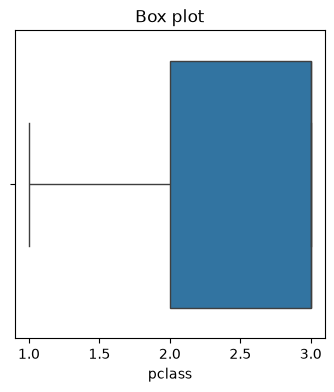

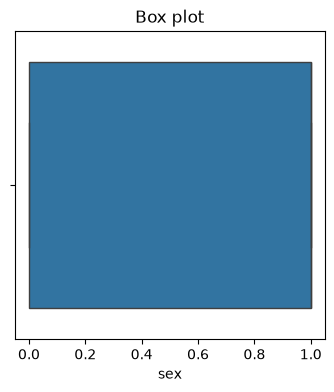

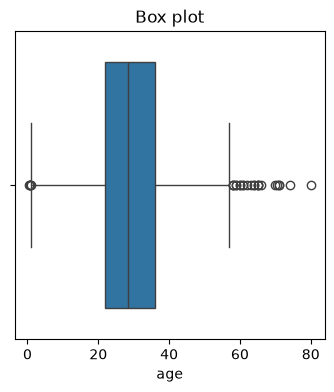

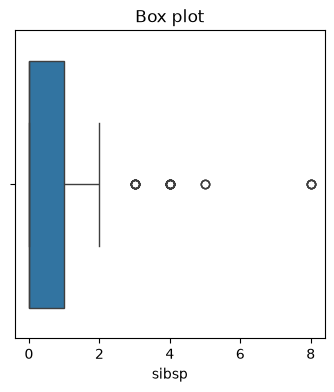

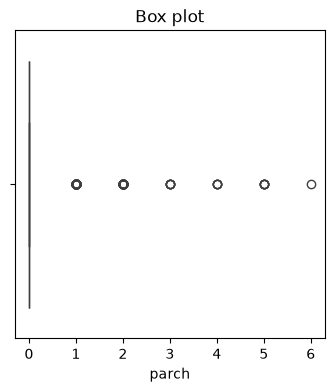

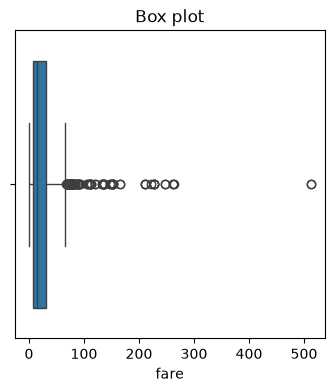

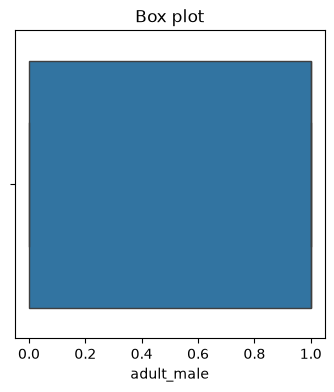

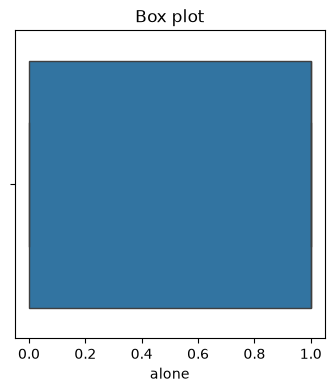

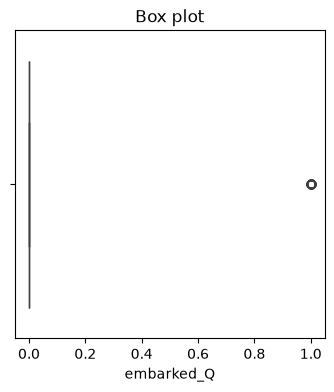

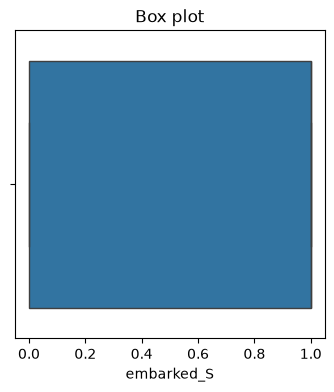

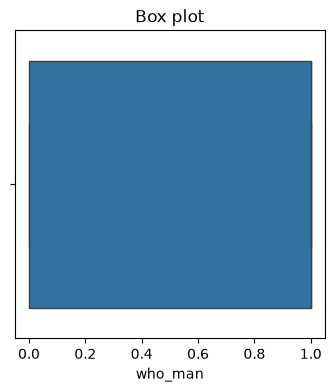

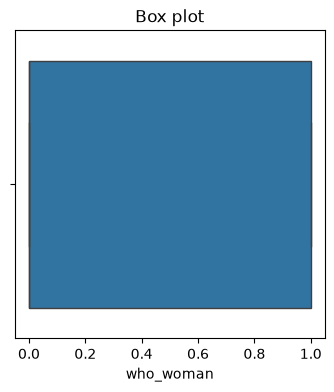

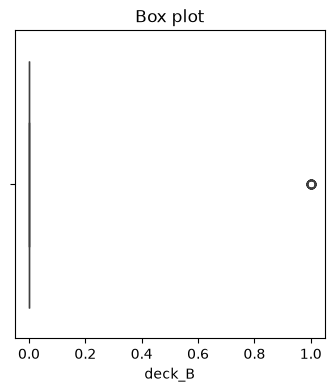

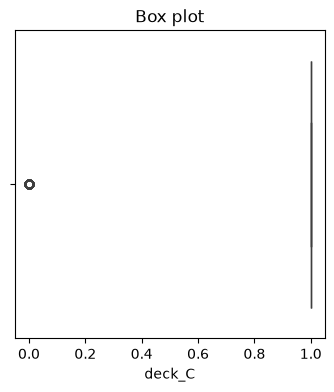

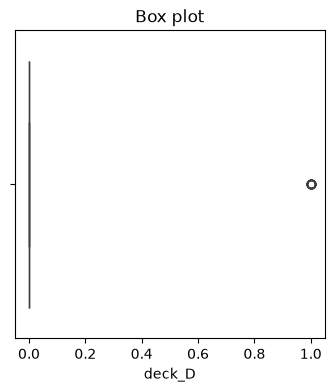

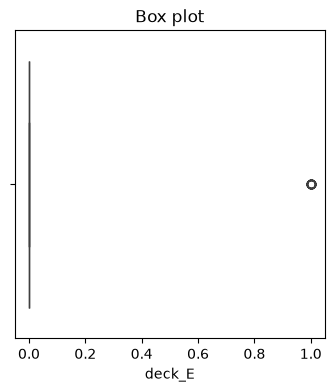

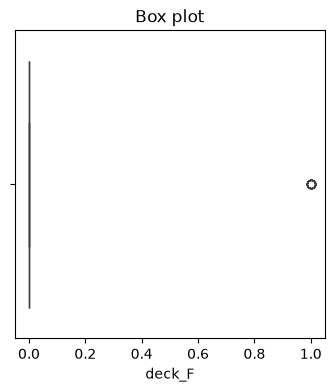

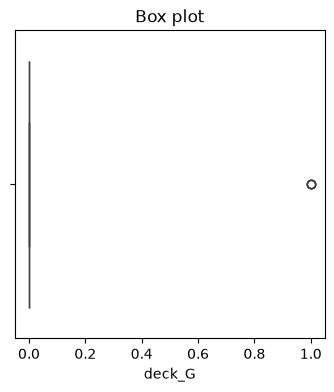

In [6]:
for col in num_cols:
    plt.figure(figsize = (4,4))
    sns.boxplot(x = X_train[col])
    plt.title("Box plot")
    plt.show()

In [9]:
valid_outliers_columns = ["age", "fare"]

In [7]:
def iqr_bound(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    higher = Q3 + 1.5 * IQR
    return lower, higher  


In [ ]:
def compute_train_bounds(df, cols):
    bounds = {}
    for col in cols:
        low, high = iqr_bound(df[col])
        bounds[col] = (low, high)
    return bounds




In [60]:
def cap_outliers_with_bounds(df, bounds):
    df_capped = df.copy()
    for col, (low, high) in bounds.items():
      
        # df_capped[col] = np.where(df_capped[col] < low, low, df_capped[col])
        # df_capped[col] = np.where(df_capped[col] > high, high, df_capped[col])
        df_capped[col] = df_capped[col].clip(lower=low, upper=high)
    return df_capped   

 

In [61]:
train_bounds = compute_train_bounds(X_train, valid_outliers_columns )
train_bounds

{'age': (np.float64(1.0), np.float64(57.0)),
 'fare': (np.float64(-26.7605), np.float64(65.6563))}

In [62]:
X_train_capped = cap_outliers_with_bounds(X_train, train_bounds)
X_test_capped = cap_outliers_with_bounds(X_test, train_bounds)

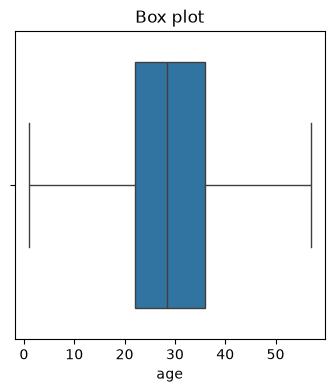

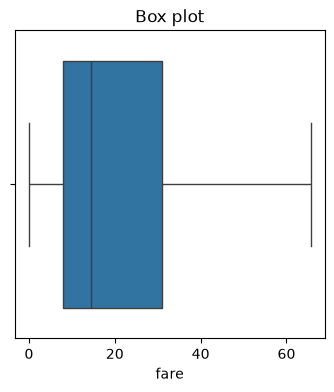

In [52]:
for col in valid_outliers_columns:
    plt.figure(figsize = (4,4))
    sns.boxplot(x = X_train_capped[col])
    plt.title("Box plot")
    plt.show()

In [53]:
train_out_df = X_train_capped.copy()
test_out_df = X_test_capped.copy()

train_out_df[target] = y_train.values
test_out_df[target] = y_test.values

train_out_df.to_csv("titanic_train_out.csv", index = False)
test_out_df.to_csv("titanic_test_out.csv", index=False)